In [1]:
import json
import serial.tools.list_ports
from windfreak import SynthHD
import time
import pyvisa
from RsInstrument import RsInstrument, BinFloatFormat
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlopen
from pathlib import Path
import os
import sys
from datetime import datetime
import matplotlib.colors as mcolors

In [2]:
rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

In [3]:
for instrument in instruments:
    print(instrument)

USB0::0x03EB::0x2065::YOKOGAWA_GS210_91U322681_2.02::INSTR
USB0::0x03EB::0x2065::Rohde_Schwarz_ZVA24-2Port_1145111024100131_3.30::INSTR
USB0::0x03EB::0x2065::Agilent_Technologies_33220A_MY44053372_2.07-2.06-2::INSTR
USB0::0x03EB::0x2065::Hewlett-Packard__E7405A__SG45102671__A.14.04::INSTR
USB0::0x03EB::0x2065::GPIB_01_24431303637351D0D031::INSTR
ASRL3::INSTR
ASRL4::INSTR


In [4]:

ports = serial.tools.list_ports.comports()
for port in ports:
    print(f"Port Name:   {port.device}")
    print(f"Description: {port.description}")
    print(f"Hardware ID: {port.hwid}")  # Shows USB Vendor ID, Product ID, and Location string
    print("-" * 30)
    if 'A3E5' in port.hwid:
        print(f"Windfreak is on COM port {port.device}")

synth = SynthHD("COM4")
synth.init()

rf_probe = synth[0]
rf_probe.enable = False
rf_probe.frequency = 5.5e9   # set Channel A frequency
rf_probe.power = -30        # set Channel A power

rf_pump = synth[1]
rf_pump.enable = False
rf_pump.frequency = 8e9   # frequency in Hz
rf_pump.power = 0        #  power in dBm


rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

noise_source_bias = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        noise_source_bias = rm.open_resource(instrument) 
        break
print(noise_source_bias.query('*IDN?').strip())

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break

spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

qubit_flux_bias = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        qubit_flux_bias = rm.open_resource(instrument) 
        break

WARM_SWITCHES_IP_ADDRESS = '169.254.12.12'
PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'

def send_url_command(ip_address, cmd_to_send):
    url = f"http://{ip_address}/:{cmd_to_send}"
    for attempt in range(3):
        try:
            with urlopen(url, timeout=3) as response:
                pte_return = response.read()
            if len(pte_return) > 100:
                print(f"Error, command not found: {url}")
                return "Invalid Command!"
            return pte_return.decode('utf-8').strip()
        except Exception as network_err:
            if attempt == 2:
                print(f"Hardware Network Warning: No response from {ip_address}. Error: {network_err}")
                return "No Response!"
            time.sleep(0.05)
            
def set_warm_switches_by_ip(ip_address, A, B, C, D):
    state_byte = 128 + int(A-1) + (2 * int(B-1)) + (4 * int(C-1)) + (8 * int(D-1))
    return send_url_command(ip_address, f"SETP={state_byte}")

def set_programmable_attenuator(attenuation):
    send_url_command(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS, f"SETATT={attenuation}")

def get_switch_state(ip_address):
    raw_reply = send_url_command(ip_address, "SWPORT?")
    if any(err in raw_reply for err in ["Error", "No Response"]):
        return {"status": "Disconnected or Error", "raw_reply": raw_reply}
    try:
        state_byte = int(raw_reply.strip())
        working_value = state_byte - 128
        return {
            "status": "Online",
            "raw_byte": state_byte,
            "A": working_value % 2 + 1,
            "B": (working_value // 2) % 2 + 1,
            "C": (working_value // 4) % 2 + 1,
            "D": (working_value // 8) % 16 + 1
        }
    except ValueError:
        return {"status": f"Malformed hardware response: {raw_reply}"}

def get_attenuator_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None
vna.go_to_local()

Port Name:   COM4
Description: USB Serial Device (COM4)
Hardware ID: USB VID:PID=0483:A3E5 SER=2068338D5232
------------------------------
Windfreak is on COM port COM4
Port Name:   COM3
Description: Intel(R) Active Management Technology - SOL (COM3)
Hardware ID: PCI\VEN_8086&DEV_02E3&SUBSYS_099F1028&REV_00\3&11583659&1&B3
------------------------------
Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2


In [5]:
set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 1, 2) #wind freak to fridge to spectrum analyzer
#A doesn't do anything, B1 is vna B2 is spa, C1 is fridge, C2 is noise diode, D1 is vna and D2 is wind freak

'1'

scan complete
33 seconds sweep time


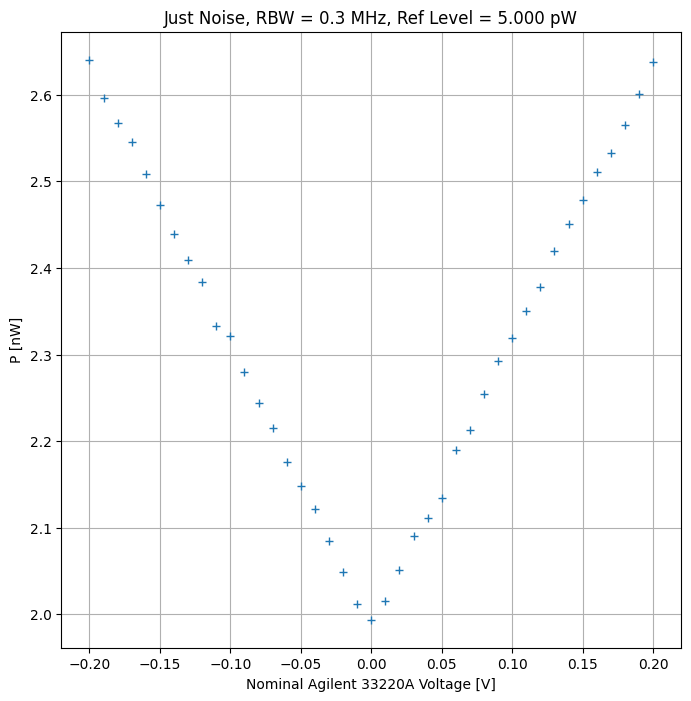

In [22]:
noise_sweep_zero_power = {}


noise_sweep_zero_power['cw_frequency'] = 5.58e9

noise_sweep_zero_power['noise_sweep_start'] = -0.2
noise_sweep_zero_power['noise_sweep_stop'] = 0.2
noise_sweep_zero_power['noise_sweep_number_of_points'] = 41

noise_sweep_zero_power['noise_bias'] = np.linspace(noise_sweep_zero_power['noise_sweep_start'], noise_sweep_zero_power['noise_sweep_stop'], noise_sweep_zero_power['noise_sweep_number_of_points'])
noise_sweep_zero_power['noise_bias'] = np.round(noise_sweep_zero_power['noise_bias']*1000)/1000
noise_sweep_zero_power['noise_bias'] = noise_sweep_zero_power['noise_bias'].tolist()

noise_sweep_zero_power['rbw'] = 0.3e6
noise_sweep_zero_power['vbw'] = 1000
noise_sweep_zero_power['ref_level'] = 5e-12

spa.write("DISP:WIND:TRAC:Y:RLEV " + str(noise_sweep_zero_power['ref_level']))

noise_sweep_zero_power['spa_id'] = spa.query("*IDN?").strip()

## attempts to fix earlier problems
spa.write(':DET SAMP')           # SAMPLE not peak
spa.write(':AVER:TYPE POW')     # Power Averaging (Stops 2.51dB Log-Video under-reporting)
spa.write(':POW:ATT 0')         # Lock Attenuation (Stops mechanical impedance shifts)

spa.write(":DEMod:STATe OFF")
spa.write(":SWEep:TIME:AUTO ON")

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

now = datetime.now().astimezone()
noise_sweep_zero_power['timestamp'] = int(now.timestamp())
noise_sweep_zero_power['date'] = now.strftime("%d-%m-%Y")
noise_sweep_zero_power['time'] = now.strftime("%H:%M:%S")
noise_sweep_zero_power['timezone'] = now.tzname()
noise_sweep_zero_power['temperature'] = '0.011'
noise_sweep_zero_power['start_time'] = int(now.timestamp())

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + noise_sweep_zero_power['date'] + " Plots\n\n")

noise_sweep_zero_power['programmable_attenuator'] = get_attenuator_state(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS)


spa.write(':SENS:BAND ' + str(noise_sweep_zero_power['rbw']))
spa.write(':SENS:BAND:VID ' + str(noise_sweep_zero_power['vbw']))
spa.write(":UNIT:POW W")

noise_sweep_zero_power['ref_level'] = float(spa.query("DISP:WIND:TRAC:Y:RLEV?").strip())

noise_sweep_zero_power['unit'] = spa.query(":UNIT:POW?").strip()

spa.write('SENSe:FREQuency:SPAN 0 Hz')
spa.write('SENSe:FREQuency:CENTer ' + str(noise_sweep_zero_power['cw_frequency']) + ' Hz')

noise_sweep_zero_power['spa_number_of_points'] = int(spa.query(':SENS1:SWEep:POINts?'))


noise_sweep_zero_power['noise'] = []
noise_sweep_zero_power['noise_sigma'] = []
noise_source_bias.write("FUNC DC")
noise_source_bias.write("OUTP ON")
for noise_bias in noise_sweep_zero_power['noise_bias']:
    print(f"V: {noise_bias} V", end="\r", flush=True)
    noise_source_bias.write("VOLT:OFFS " + str(noise_bias))
    while True:
        try:
            spa.write("INIT:IMM")
            spa.query("*OPC?")
            trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
            if np.isnan(trace).any():
                raise ValueError
            noise_sweep_zero_power['noise'].append(np.mean(trace))
            noise_sweep_zero_power['noise_sigma'].append(np.std(trace))
            break
        except (pyvisa.errors.VisaIOError, ValueError):
            spa.clear()
            time.sleep(0.1)
    time.sleep(0.05)
noise_source_bias.write("VOLT:OFFS 0.0")
print("scan complete")

now = datetime.now().astimezone()
noise_sweep_zero_power['finish_time'] = int(now.timestamp())
noise_sweep_zero_power['sweep_time'] = noise_sweep_zero_power['finish_time'] - noise_sweep_zero_power['start_time']
print(str(noise_sweep_zero_power['sweep_time']) + " seconds sweep time")
sweep_file_name = f"{noise_sweep_zero_power['timestamp']}-noise-sweep-zero-power.json"
file_path = target_dir / sweep_file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(noise_sweep_zero_power, f, indent=4)

plt.figure(figsize=(8,8))
plt.tight_layout()
plt.plot(noise_sweep_zero_power['noise_bias'],np.array(noise_sweep_zero_power['noise'])/1e-12,"+")
plt.xlabel('Nominal Agilent 33220A Voltage [V]')
plt.ylabel('P [nW]')
plt.title('Just Noise, RBW = ' + str(noise_sweep_zero_power['rbw']/1e6) + ' MHz, Ref Level = ' +  f"{noise_sweep_zero_power['ref_level']/1e-12:.3f}" + " pW")
plt.grid()

plot_file_name = f"{noise_sweep_zero_power['timestamp']}-noise-sweep-zero-power-plot.png"

with open(readme_path, "a") as file:
    file.write("\n![]("+ plot_file_name + ")\n")

with open(readme_path, "a") as file:
    file.write("\n### ["+ sweep_file_name + "]("+ sweep_file_name + ")\n")

plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
plt.show()



In [45]:
noise_source_bias.query("*IDN?").strip()

'Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2'

In [35]:
int(spa.query(':SENS1:SWEep:POINts?').strip())



1001

In [37]:
noise_sweep_zero_power['ref_level']

1.66e-09

In [38]:
spa.write("DISP:WIND:TRAC:Y:RLEV 0.1e-09")

31

In [41]:
noise_sweep_zero_power['unit']

'W'

In [68]:
synth.close()

In [5]:
noise_source_bias.write("VOLT:OFFS 0.0")


15

In [9]:
spa.query(':SWE:TIME:AUTO?')

'0\n'

In [7]:
spa.write(':SWE:TIME:AUTO ON')

19

In [10]:
spa.query(':SWE:TIME:AUTO?')

'0\n'

In [18]:
spa.write("DISP:WIND:TRAC:Y:RLEV 100e-12")


31

In [15]:
spa.write(':SENS:BAND:VID 1e3')

20

In [16]:
noise_sweep_zero_power['rbw'] = 0.3e6
spa.write(':SENS:BAND ' + str(noise_sweep_zero_power['rbw']))


21

In [23]:
synth.close()